# Notebook 04 – Exploratory Data Analysis
**Goal:** understand the distribution of road accidents across Italian municipalities and identify patterns, trends and outliers.

**Reference year:** most analyses use **2023**, the last year in which all municipalities are listed (including those with 0 accidents). 2024 is excluded from comparisons because it only lists municipalities with at least 1 accident, which inflates the average rates.

**Data:** `Data/Processed/integrated_clean.csv` – one row per municipality and year (2001–2024), matched municipalities only where population and area are needed.

**1. Load the integrated table** 
* One row per municipality and year (2001–2024), with accidents, injured, deaths, population, area and the two rates.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Data/Processed/integrated_clean.csv", keep_default_na=False, na_values=[""])
print(df.shape)       
df.head(3)

(191184, 14)


,REF_AREA,TIME_PERIOD,accidents,deaths,injured,Comune,Sigla automobilistica,Codice Regione,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione residente,Superficie (Kmq),accidents_per_1000,accidents_per_km2
0,1001,2001,5,0,10,Agliè,TO,1,0,0,2585,13.1463,1.934236,0.380335
1,1001,2002,5,0,10,Agliè,TO,1,0,0,2585,13.1463,1.934236,0.380335
2,1001,2003,4,0,7,Agliè,TO,1,0,0,2585,13.1463,1.547389,0.304268


**2. Descriptive statistics by year** 
* Mean, median and maximum of the accident rate per 1,000 inhabitants.

In [19]:
df_2023 = df[(df["TIME_PERIOD"] == 2023) & (df["Comune"].notna())]
print("Municipalities in 2023:", len(df_2023))   
df_2023[["accidents", "accidents_per_1000", "accidents_per_km2"]].describe().round(2)

Municipalities in 2023: 7892


,accidents,accidents_per_1000,accidents_per_km2
count,7892.00,7892.00,7892.00
mean,21.10,1.77,0.62
std,193.25,1.91,1.64
min,0.00,0.00,0.00
25%,1.00,0.51,0.02
50%,3.00,1.46,0.14
75%,11.00,2.48,0.51
max,12817.00,31.25,42.96


**3. Accidents over time** 
* National total per year, matched municipalities only. The 2020 drop is due to Covid-19 lockdowns.

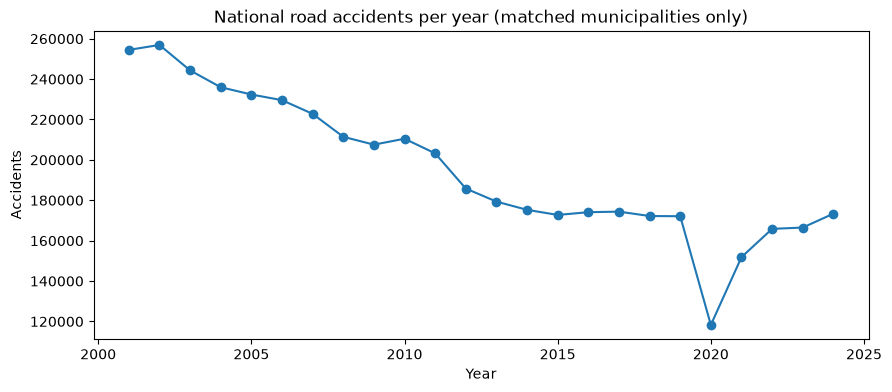

In [20]:
by_year = df[df["Comune"].notna()].groupby("TIME_PERIOD")["accidents"].sum().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(by_year["TIME_PERIOD"], by_year["accidents"], marker="o")
plt.title("National road accidents per year (matched municipalities only)")
plt.xlabel("Year")
plt.ylabel("Accidents")
plt.show()

### Summary of the 2002–2024 Decline

* **Strict Legislation:** The introduction of the penalty point license (patente a punti) in July 2003 drastically deterred reckless driving, while subsequent harsher laws for driving under the influence and the creation of the vehicular homicide crime (omicidio stradale) reinforced compliance.
* **Speed Technology:** Massive implementation of speed traps like Autovelox and the Tutor system on motorways structurally reduced average speeds across the country.
* **Vehicle Safety:** Active and passive safety tech—such as ABS, airbags, and ESP—became mandatory standards. Meanwhile, newer car fleets achieved much higher crash test ratings compared to older '80s and '90s models.
* **Economic Recessions:** Deep financial crises (such as the 2008–2013 downturn) resulted in fewer total kilometers driven due to reduced cargo transport and personal leisure trips, mechanically lowering the odds of collisions.


**3. Accidents over time**
* **General Trend (2001–2019):** The national total falls from 263,100 (2001) to 172,183 (2019), a drop of about 35%. The average per municipality falls from 33.8 to 21.8 over the same period, confirming that the trend is real and not caused by fewer municipalities being listed.
* **The 2020 Drop & 2024 Data:** The 2020 drop (−31% vs 2019) is due to Covid-19 lockdowns. The 2024 average per municipality appears higher because only municipalities with at least 1 accident are listed that year.

In [21]:
check = df[df["Comune"].notna()].groupby("TIME_PERIOD").agg(
    municipalities=("REF_AREA", "count"),
    total_accidents=("accidents", "sum"),
    accidents_per_municipality=("accidents", "mean"),
).reset_index()
check

,TIME_PERIOD,municipalities,total_accidents,accidents_per_municipality
0,2001,7534,254474,33.776745
1,2002,7535,256915,34.096218
2,2003,7535,244303,32.422429
3,2004,7535,235979,31.317717
4,2005,7536,232372,30.834926
5,2006,7499,229576,30.614215
6,2007,7499,222795,29.709961
7,2008,7499,211432,28.194693
8,2009,7500,207545,27.672667
9,2010,7614,210480,27.643814


**4. Top 10 municipalities by accident rate (2023)** 
* Filtered to municipalities with more than 10,000 residents to avoid small towns where one accident gives an unrealistically high rate. Two rankings: by rate per 1,000 inhabitants (who has proportionally more accidents) and by rate per km² (where accidents are most concentrated).

In [22]:
df_2023 = df[(df["TIME_PERIOD"] == 2023) & (df["Comune"].notna()) & (df["Popolazione residente"] > 10000)]
top_1000 = (
    df_2023
    .sort_values("accidents_per_1000", ascending=False)
    .head(10)[["Comune", "accidents", "Popolazione residente", "accidents_per_1000"]]
)
top_km2 = (
    df_2023
    .sort_values("accidents_per_km2", ascending=False)
    .head(10)[["Comune", "accidents", "Superficie (Kmq)", "accidents_per_km2"]]
)
print(top_1000.to_string())
print()
print(top_km2.to_string())

                      Comune  accidents  Popolazione residente  accidents_per_1000
30322                Lavagna        103                  12367            8.328616
28701          Finale Ligure         86                  11012            7.809662
45190                Bergamo        891                 120389            7.401008
183591              Riccione        253                  34340            7.367501
104193               Firenze       2580                 361705            7.132885
103964             Calenzano        126                  17994            7.002334
103898  Barberino di Mugello         73                  10939            6.673371
28820                  Loano         71                  10688            6.642964
103272             Viareggio        398                  60618            6.565707
30251                 Genova       3669                 564080            6.504397

                    Comune  accidents  Superficie (Kmq)  accidents_per_km2
42961      

**5. Boxplot: distribution of accident rates (2023)** 
* Both distributions are heavily right-skewed: most municipalities have a low rate, while a small number of dense urban areas are extreme outliers. The box (25th–75th percentile) is very narrow compared to the whiskers, confirming the imbalance.

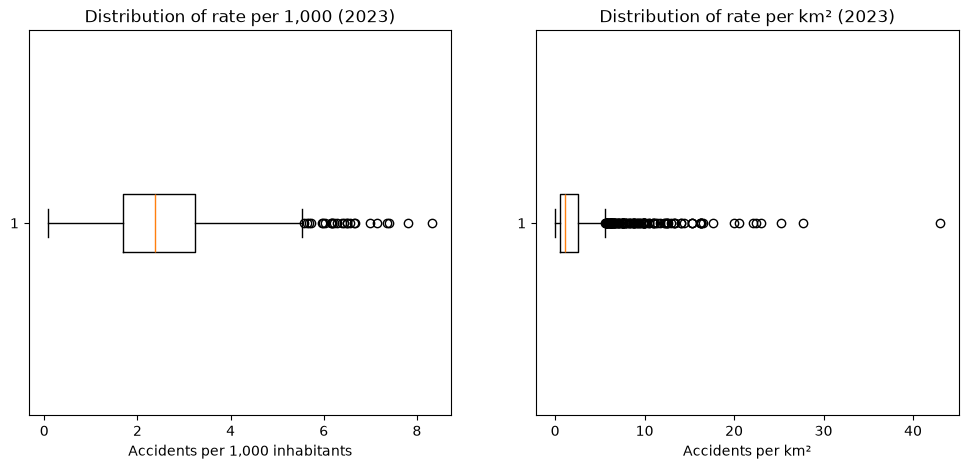

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_2023["accidents_per_1000"].dropna(),orientation='horizontal')
axes[0].set_xlabel("Accidents per 1,000 inhabitants")
axes[0].set_title("Distribution of rate per 1,000 (2023)")

axes[1].boxplot(df_2023["accidents_per_km2"].dropna(), orientation='horizontal')
axes[1].set_xlabel("Accidents per km²")
axes[1].set_title("Distribution of rate per km² (2023)")

plt.show()

**6. Scatter: rate per 1,000 vs rate per km² (2023)** 
* Most municipalities cluster near the origin (low on both axes). Cities with high density (km²) do not always have a high rate per inhabitant, and vice versa. The two indicators capture different dimensions of the accident risk.

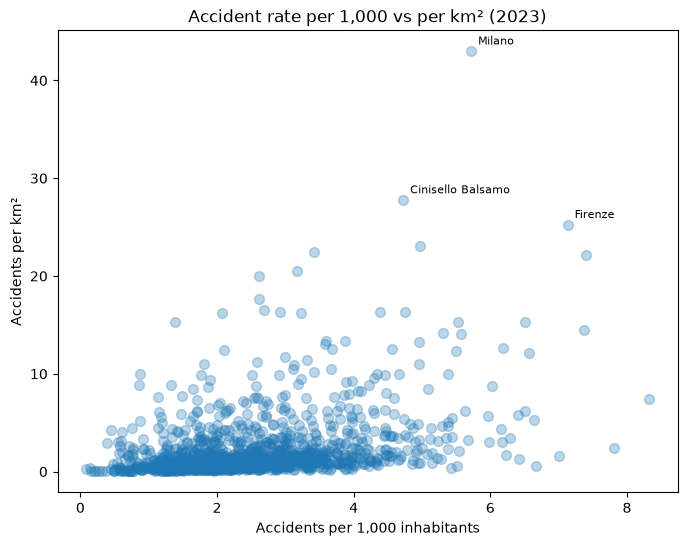

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_2023["accidents_per_1000"],
    df_2023["accidents_per_km2"],
    alpha=0.3, s=50)

cities = ["Milano", "Firenze", "Cinisello Balsamo"]
to_label = df_2023[df_2023["Comune"].isin(cities)]

for _, row in to_label.iterrows():
    ax.annotate(row["Comune"], (row["accidents_per_1000"], row["accidents_per_km2"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")
    
ax.set_xlabel("Accidents per 1,000 inhabitants")
ax.set_ylabel("Accidents per km²")
ax.set_title("Accident rate per 1,000 vs per km² (2023)")
plt.show()